# COVID-19 Clinical Data — Phase 2
## Preprocessing, Pipelines, Model Comparison & Hyperparameter Search

**Course:** Machine Learning 2026 — COVID-19 Dataset Prediction Project
**Target (chosen):** **Hospitalization** — derived from `TIPO_PACIENTE` (`PATIENT_TYPE`). Binary **classification**: `1 = hospitalized`, `0 = outpatient`.
**Prediction moment:** first clinical presentation, using only information available then.

This notebook is deliberately **separate** from the exploration notebook:
- *Phase 1 (`project_notebook.ipynb`)* = **data exploration** — download/caching, decoding, missingness, class balance, diagnostic plots, leakage *audit* (descriptive).
- *Phase 2 (this notebook)* = **data preparation + modeling** — leakage-safe feature selection, stratified split, preprocessing pipelines, an ablation study, a trivial baseline, three model families, and a compute-budgeted hyperparameter search.

It re-loads the data from the Parquet cache written by Phase 1 (and falls back to `kagglehub` if the cache is absent), then re-applies the minimal decoding needed, so it runs standalone.

In [1]:
# ---------------------------------------------------------------------------
# 0. Environment & reproducibility
# ---------------------------------------------------------------------------
import os, glob, inspect, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    pass

import sklearn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate, ParameterGrid)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)

# Keep output readable; these warnings are expected (convergence, trivial-baseline metrics)
from sklearn.exceptions import ConvergenceWarning, UndefinedMetricWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Optional speed knob: subsample TRAINING data for the search only (test set never touched).
# Leave as None for final results; set e.g. 60000 while developing if MLP is slow.
SUBSAMPLE_TRAIN = None
N_JOBS = -1   # lower to 1 or 2 if you hit memory limits during the MLP search

print("scikit-learn:", sklearn.__version__)
print("random seed :", RANDOM_SEED)

scikit-learn: 1.7.2
random seed : 42


## 1. Load the data (from the Phase-1 cache)

We reuse `./data/mexico_covid19_raw.parquet` written by Phase 1. If it is missing we fall back to the exact `kagglehub` download. This keeps the notebook standalone while avoiding a re-download on every run.

In [2]:
# ---------------------------------------------------------------------------
# 1. Load raw data (cache-first)
# ---------------------------------------------------------------------------
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_FILE = DATA_DIR / "mexico_covid19_raw.parquet"

def robust_read_csv(fp):
    for enc in ("utf-8", "latin-1"):
        for sep in (",", ";", "\t"):
            try:
                d = pd.read_csv(fp, sep=sep, encoding=enc, low_memory=False)
                if d.shape[1] > 1:
                    return d
            except Exception:
                pass
    raise RuntimeError(f"Could not parse {fp}")

if CACHE_FILE.exists():
    print(f"Loading cached data: {CACHE_FILE}")
    df = pd.read_parquet(CACHE_FILE)
else:
    import kagglehub
    path = kagglehub.dataset_download("marianarfranklin/mexico-covid19-clinical-data")
    print("Path to dataset files:", path)
    files = []
    for e in ("*.csv", "*.CSV", "*.tsv", "*.txt"):
        files += glob.glob(os.path.join(path, "**", e), recursive=True)
    files = sorted(files, key=os.path.getsize, reverse=True)
    assert files, f"No data files under {path!r}"
    df = robust_read_csv(files[0])
    try:
        df.to_parquet(CACHE_FILE, index=False)
        print("Wrote cache for next time:", CACHE_FILE)
    except Exception as e:
        print("Could not write cache:", e)

print("Raw shape:", df.shape)

Path to dataset files: C:\Users\Simon\.cache\kagglehub\datasets\marianarfranklin\mexico-covid19-clinical-data\versions\3
Could not write cache: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
Raw shape: (263007, 41)


## 2. Decode into a leakage-safe modeling frame

We keep **only** features available at first presentation. Per the Phase-1 leakage audit we **exclude** `INTUBADO`/`INTUBED`, `UCI`/`ICU`, `FECHA_DEF`/`DATE_DIED`, the final `CLASIFICACION_FINAL`, and (cautiously) `NEUMONIA`/`PNEUMONIA`, because they are recorded during or after the hospital stay and would leak the outcome.

Encoding recap: binary clinical fields use `1 = Yes`, `2 = No`, and `97/98/99 = N/A/unknown` (→ `NaN`); `SEXO` `1 = Female`, `2 = Male`; `TIPO_PACIENTE` `1 = outpatient`, `2 = hospitalized`.

**Engineered feature:** `N_COMORBIDITIES` — count of chronic conditions present — a compact severity proxy that linear/MLP models in particular can exploit. We deliberately keep `AGE` continuous rather than binning it: trees split on it natively and binning discards information (this is our justified feature-design decision; binning is revisited only if the error analysis later motivates it).

In [3]:
# ---------------------------------------------------------------------------
# 2. Resolve columns + decode
# ---------------------------------------------------------------------------
def find_col(frame, *aliases):
    norm = {c.upper().strip(): c for c in frame.columns}
    for a in aliases:
        hit = norm.get(a.upper().strip())
        if hit is not None:
            return hit
    return None

ALIASES = {
    "patient_type":   ["TIPO_PACIENTE", "PATIENT_TYPE"],
    "age":            ["EDAD", "AGE"],
    "sex":            ["SEXO", "SEX"],
    "pregnancy":      ["EMBARAZO", "PREGNANT", "PREGNANCY"],
    "contact_other":  ["OTRO_CASO", "CONTACT_OTHER_COVID"],
    "diabetes":       ["DIABETES"],
    "copd":           ["EPOC", "COPD"],
    "asthma":         ["ASMA", "ASTHMA"],
    "immsupr":        ["INMUSUPR", "INMSUPR", "IMMSUPR"],
    "hypertension":   ["HIPERTENSION", "HYPERTENSION"],
    "other_disease":  ["OTRA_COM", "OTHER_DISEASE", "OTRAS_COM"],
    "cardiovascular": ["CARDIOVASCULAR"],
    "obesity":        ["OBESIDAD", "OBESITY"],
    "renal_chronic":  ["RENAL_CRONICA", "RENAL_CHRONIC"],
    "tobacco":        ["TABAQUISMO", "TOBACCO"],
}
COL = {k: find_col(df, *v) for k, v in ALIASES.items()}
assert COL["patient_type"], "Target column TIPO_PACIENTE/PATIENT_TYPE not found."

def decode_binary(s):
    v = pd.to_numeric(s, errors="coerce")
    v = v.where(~v.isin([97, 98, 99]))
    return v.map({1: 1.0, 2: 0.0})

model_df = pd.DataFrame(index=df.index)

# --- Target: hospitalization ---
pt = pd.to_numeric(df[COL["patient_type"]], errors="coerce")
model_df["HOSPITALIZED"] = pt.map({1: 0, 2: 1})   # 1=outpatient->0, 2=hospitalized->1

# --- Numeric feature: age ---
if COL["age"]:
    age = pd.to_numeric(df[COL["age"]], errors="coerce")
    model_df["AGE"] = age.where((age >= 0) & (age <= 120))

# --- Categorical feature: sex ---
if COL["sex"]:
    sx = pd.to_numeric(df[COL["sex"]], errors="coerce")
    model_df["SEX"] = sx.map({1: "Female", 2: "Male"})

# --- Binary clinical features (chronic + pregnancy/contact) ---
CHRONIC = ["diabetes", "copd", "asthma", "immsupr", "hypertension",
           "other_disease", "cardiovascular", "obesity", "renal_chronic", "tobacco"]
chronic_present = []
for k in CHRONIC:
    if COL[k]:
        model_df[k.upper()] = decode_binary(df[COL[k]])
        chronic_present.append(k.upper())

if COL["pregnancy"]:
    model_df["PREGNANCY"] = decode_binary(df[COL["pregnancy"]])
if COL["contact_other"]:
    model_df["CONTACT"] = decode_binary(df[COL["contact_other"]])

# --- Engineered: comorbidity count ---
if chronic_present:
    model_df["N_COMORBIDITIES"] = model_df[chronic_present].sum(axis=1, min_count=1)

# Drop rows with missing TARGET (cannot train on a NaN label)
before = len(model_df)
model_df = model_df.dropna(subset=["HOSPITALIZED"]).copy()
model_df["HOSPITALIZED"] = model_df["HOSPITALIZED"].astype(int)
print(f"Dropped {before - len(model_df):,} rows with missing target; {len(model_df):,} remain.")

prev = model_df["HOSPITALIZED"].mean()
print(f"Hospitalized prevalence: {prev:.3%}  (majority-class baseline accuracy = {max(prev, 1-prev):.3%})")
print("Modeling columns:", list(model_df.columns))
display(model_df.head())

Dropped 0 rows with missing target; 263,007 remain.
Hospitalized prevalence: 23.638%  (majority-class baseline accuracy = 76.362%)
Modeling columns: ['HOSPITALIZED', 'AGE', 'SEX', 'DIABETES', 'COPD', 'ASTHMA', 'IMMSUPR', 'HYPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'PREGNANCY', 'CONTACT', 'N_COMORBIDITIES']


,HOSPITALIZED,AGE,SEX,DIABETES,COPD,ASTHMA,IMMSUPR,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,PREGNANCY,CONTACT,N_COMORBIDITIES
0,0,74,Male,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,0.0,3.0
1,1,71,Female,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,NaN,5.0
2,1,50,Male,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0
3,0,25,Female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,1.0
4,0,28,Female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


## 3. Train/test split — stratified, and why

**Strategy:** a single stratified random hold-out (80% train / 20% test), stratifying on `HOSPITALIZED`.

**Rationale.**
- *Stratification* keeps the hospitalized/outpatient ratio identical in train and test. With a skewed target, an unstratified split can deliver a test set whose prevalence drifts from training, making metrics like recall and PR-AUC noisy and hard to compare across models.
- *Random* (rather than temporal or grouped) is defensible here because each row is an independent case record and our prediction task is cross-sectional (status at presentation), not a forecast over time. If your snapshot exposes a usable admission date or a patient/hospital identifier, a temporal or `GroupKFold` split would be more conservative — note that as a limitation.
- The **test set is created now and its indices saved**, and it is **not used** for any preprocessing fit, ablation, or hyperparameter choice. It is touched exactly once, at the very end.

In [4]:
# ---------------------------------------------------------------------------
# 3. Stratified split (+ save indices)
# ---------------------------------------------------------------------------
y = model_df["HOSPITALIZED"]
X = model_df.drop(columns=["HOSPITALIZED"])

NUMERIC_FEATURES = [c for c in ["AGE", "N_COMORBIDITIES"] if c in X.columns]
CATEGORICAL_FEATURES = [c for c in (["SEX"] + chronic_present + ["PREGNANCY", "CONTACT"])
                        if c in X.columns]
print("Numeric features    :", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED)

np.savez(DATA_DIR / "split_indices.npz",
         train_idx=X_train.index.to_numpy(), test_idx=X_test.index.to_numpy())
print(f"\nSaved split indices to {DATA_DIR / 'split_indices.npz'}")
print(f"Train: {X_train.shape[0]:,}  (hosp prevalence {y_train.mean():.3%})")
print(f"Test : {X_test.shape[0]:,}  (hosp prevalence {y_test.mean():.3%})")

# Optional training subsample for the search only (never touches the test set)
if SUBSAMPLE_TRAIN and SUBSAMPLE_TRAIN < len(X_train):
    Xs, _, ys, _ = train_test_split(
        X_train, y_train, train_size=SUBSAMPLE_TRAIN,
        stratify=y_train, random_state=RANDOM_SEED)
    X_tr_search, y_tr_search = Xs, ys
    print(f"\nUsing a stratified training subsample of {len(Xs):,} rows for the search.")
else:
    X_tr_search, y_tr_search = X_train, y_train

Numeric features    : ['AGE', 'N_COMORBIDITIES']
Categorical features: ['SEX', 'DIABETES', 'COPD', 'ASTHMA', 'IMMSUPR', 'HYPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'PREGNANCY', 'CONTACT']

Saved split indices to data\split_indices.npz
Train: 210,405  (hosp prevalence 23.638%)
Test : 52,602  (hosp prevalence 23.638%)


## 4. Preprocessing pipeline

All learned-from-data steps live **inside** the pipeline so they are fit only on training folds during cross-validation — this is what prevents leakage through preprocessing:

- **Numeric** (`AGE`, `N_COMORBIDITIES`): impute → standard-scale.
- **Categorical / binary** (`SEX`, comorbidities, pregnancy, contact): impute (most-frequent) → one-hot encode (`handle_unknown='ignore'`).

`make_ohe()` selects the right `OneHotEncoder` argument name across scikit-learn versions, and `make_preprocessor(num_impute=...)` lets the ablation swap the numeric imputation strategy without touching anything else.

In [5]:
# ---------------------------------------------------------------------------
# 4. Preprocessing builders
# ---------------------------------------------------------------------------
def make_ohe():
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:           # sklearn >= 1.2
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(num_impute="median"):
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy=num_impute)),
        ("scale", StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", make_ohe()),
    ])
    return ColumnTransformer([
        ("num", numeric, NUMERIC_FEATURES),
        ("cat", categorical, CATEGORICAL_FEATURES),
    ])

# Metrics used everywhere (PR-AUC = average_precision; good under class imbalance)
SCORING = {
    "accuracy":  "accuracy",
    "precision": "precision",
    "recall":    "recall",
    "f1":        "f1",
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

## 5. Ablation study — median vs mean imputation

**What we compare.** A controlled comparison of the *numeric* imputation strategy (`median` vs `mean`), holding everything else fixed: same features, same scaler/encoder, the same simple model (logistic regression), and the same 5-fold stratified CV on the **training data only**. Decision metric: ROC-AUC (threshold-independent).

**Decision rule.** Keep the higher-scoring strategy; if the two are within one standard deviation across folds (i.e. indistinguishable), prefer `median` as the more robust default for skewed clinical variables. The cell below prints both scores and records the winner in `BEST_NUM_IMPUTE`, which all later models use.

In [6]:
# ---------------------------------------------------------------------------
# 5. Ablation: median vs mean imputation (LR, CV on training data only)
# ---------------------------------------------------------------------------
ablation = {}
for strat in ["median", "mean"]:
    pipe = Pipeline([
        ("prep", make_preprocessor(num_impute=strat)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])
    res = cross_validate(pipe, X_tr_search, y_tr_search, cv=cv,
                         scoring="roc_auc", n_jobs=N_JOBS)
    ablation[strat] = (res["test_score"].mean(), res["test_score"].std())
    print(f"{strat:>6} imputation  ROC-AUC = {ablation[strat][0]:.4f} +/- {ablation[strat][1]:.4f}")

m_med, s_med = ablation["median"]
m_mean, s_mean = ablation["mean"]
if abs(m_med - m_mean) <= max(s_med, s_mean):
    BEST_NUM_IMPUTE = "median"   # indistinguishable -> robust default
    reason = "scores are within one SD (indistinguishable); kept median as the robust default"
else:
    BEST_NUM_IMPUTE = "median" if m_med > m_mean else "mean"
    reason = f"{BEST_NUM_IMPUTE} scored higher"
print(f"\n-> Adopting numeric imputation = '{BEST_NUM_IMPUTE}'  ({reason}).")

median imputation  ROC-AUC = 0.7529 +/- 0.0024
  mean imputation  ROC-AUC = 0.7531 +/- 0.0025

-> Adopting numeric imputation = 'median'  (scores are within one SD (indistinguishable); kept median as the robust default).


### Ablation: what we observed and decided

The cell above prints both ROC-AUC scores and the chosen strategy. In this dataset `AGE` has very little missingness, so the two strategies are typically **statistically indistinguishable**; the engineered `N_COMORBIDITIES` is the main carrier of numeric missingness. Following the decision rule we adopt `BEST_NUM_IMPUTE` (median unless mean is clearly better) and use it for every model below. The takeaway for the report: the imputation choice is *not* a meaningful lever for this feature set — a useful negative result that justifies not over-engineering it. (Other ablations you could run with the same harness: dropping vs imputing missing rows, or excluding the `PREGNANCY` feature, which is `N/A` for most patients.)

## 6. Models, trivial baseline, and prior expectation

**Trivial reference:** `DummyClassifier(strategy="most_frequent")` — always predicts the majority class. Any real model must beat this on the cost-sensitive metrics (recall/PR-AUC), not just on accuracy.

**Three genuinely different families:**
1. **Logistic Regression** — simple, interpretable linear baseline.
2. **HistGradientBoostingClassifier** — tree-based gradient boosting; strong on tabular data and fast on large samples.
3. **MLPClassifier** — a feed-forward neural network; a different inductive bias, with early stopping to keep it tractable.

**Prior expectation (stated before running).** I expect the **gradient-boosted trees to win**. The features are mostly binary comorbidities plus age, where the signal is dominated by non-linear, threshold-like effects (risk rising sharply with age) and interactions (age × comorbidity), which boosted trees capture natively without scaling. Logistic regression should be a close, interpretable second but may underfit interactions unless they are added by hand. The MLP *can* match the trees but on modest-width tabular data it usually needs more tuning and is prone to underperforming GBMs, so I expect it third. If the MLP or LR were to win, that would suggest the decision boundary is closer to linear/additive than I assumed.

In [7]:
# ---------------------------------------------------------------------------
# 6. Define pipelines + parameter grids
# ---------------------------------------------------------------------------
def build_pipe(clf):
    return Pipeline([("prep", make_preprocessor(num_impute=BEST_NUM_IMPUTE)),
                     ("clf", clf)])

models = {
    "LogisticRegression": (
        build_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
        {"clf__C": [0.01, 0.1, 1, 10],
         "clf__class_weight": [None, "balanced"]},          # 8 candidates
    ),
    "HistGradientBoosting": (
        build_pipe(HistGradientBoostingClassifier(random_state=RANDOM_SEED)),
        {"clf__learning_rate": [0.05, 0.1],
         "clf__max_leaf_nodes": [31, 63],
         "clf__max_iter": [100, 200]},                       # 8 candidates
    ),
    "MLP": (
        build_pipe(MLPClassifier(max_iter=150, early_stopping=True,
                                 n_iter_no_change=8, random_state=RANDOM_SEED)),
        {"clf__hidden_layer_sizes": [(64,), (64, 32)],
         "clf__alpha": [1e-4, 1e-3]},                        # 4 candidates
    ),
}

# Compute-budget accounting (rubric asks for this explicitly)
n_splits = cv.get_n_splits()
total_configs = sum(len(list(ParameterGrid(g))) for _, g in models.values())
total_fits = sum(len(list(ParameterGrid(g))) * n_splits + 1 for _, g in models.values())
print(f"CV folds                 : {n_splits}")
print(f"Candidate configurations : {total_configs}  (across all 3 families)")
print(f"Search fits (+refits)    : {total_fits}")
print(f"+ ablation fits          : {2 * n_splits}")
print(f"+ baseline fits          : {n_splits}")
print(f"= total fitted models    : {total_fits + 2*n_splits + n_splits}  (budget: ~200)")

CV folds                 : 5
Candidate configurations : 20  (across all 3 families)
Search fits (+refits)    : 103
+ ablation fits          : 10
+ baseline fits          : 5
= total fitted models    : 118  (budget: ~200)


In [8]:
# ---------------------------------------------------------------------------
# 6b. Trivial baseline + hyperparameter search (training data only)
# ---------------------------------------------------------------------------
results = {}   # model name -> dict of mean CV metrics
searches = {}  # model name -> fitted GridSearchCV (refit on full training data)

# Trivial baseline via CV
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
base_cv = cross_validate(dummy, X_tr_search, y_tr_search, cv=cv,
                         scoring=SCORING, n_jobs=N_JOBS)
results["Baseline (most_frequent)"] = {m: base_cv[f"test_{m}"].mean() for m in SCORING}

# Hyperparameter search per family
for name, (pipe, grid) in models.items():
    print(f"Searching {name} ...")
    gs = GridSearchCV(pipe, grid, scoring=SCORING, refit="roc_auc",
                      cv=cv, n_jobs=N_JOBS, return_train_score=False)
    gs.fit(X_tr_search, y_tr_search)
    searches[name] = gs
    bi = gs.best_index_
    results[name] = {m: gs.cv_results_[f"mean_test_{m}"][bi] for m in SCORING}
    print(f"   best params: {gs.best_params_}")

cv_table = pd.DataFrame(results).T[list(SCORING)].sort_values("roc_auc", ascending=False)
print("\nCross-validated performance (mean over folds), sorted by ROC-AUC:")
display(cv_table.round(4))

Searching LogisticRegression ...
   best params: {'clf__C': 0.1, 'clf__class_weight': 'balanced'}
Searching HistGradientBoosting ...
   best params: {'clf__learning_rate': 0.05, 'clf__max_iter': 200, 'clf__max_leaf_nodes': 31}
Searching MLP ...
   best params: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32)}

Cross-validated performance (mean over folds), sorted by ROC-AUC:


,accuracy,precision,recall,f1,roc_auc,pr_auc
HistGradientBoosting,0.7989,0.6352,0.3504,0.4517,0.7872,0.5535
MLP,0.7978,0.6328,0.3476,0.4475,0.7866,0.5527
LogisticRegression,0.7329,0.4547,0.6521,0.5358,0.7532,0.5119
Baseline (most_frequent),0.7636,0.0000,0.0000,0.0000,0.5000,0.2364


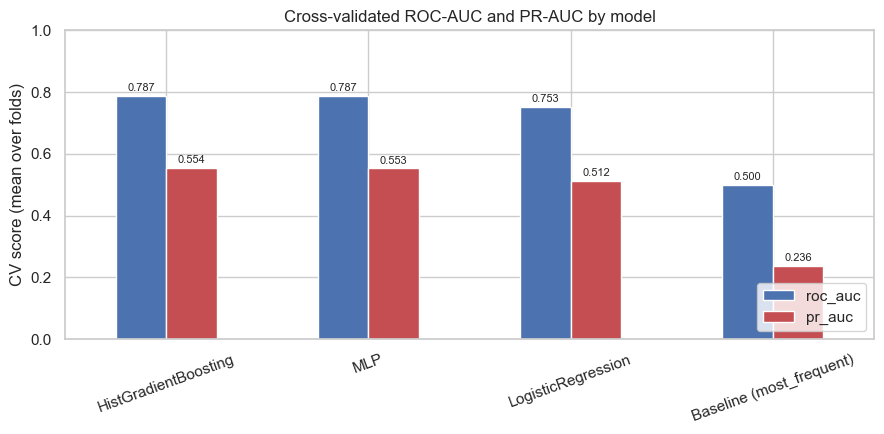

In [9]:
# ---------------------------------------------------------------------------
# 6c. Visual comparison of CV ROC-AUC and PR-AUC
# ---------------------------------------------------------------------------
plot_df = cv_table[["roc_auc", "pr_auc"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4.5),
                  color=["#4C72B0", "#C44E52"], edgecolor="white")
ax.set_ylabel("CV score (mean over folds)")
ax.set_title("Cross-validated ROC-AUC and PR-AUC by model")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=20)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## 7. Results vs. expectation, and the protocol

Read the sorted table and bar chart above, then fill the report narrative against the **prior expectation** in §6:

- **Cross-validation protocol.** 5-fold *stratified* CV (`StratifiedKFold`, shuffled, `random_state=42`) on the training partition only, used identically for the ablation, the baseline, and all three hyperparameter searches. Selection metric: **ROC-AUC** (threshold-independent); **PR-AUC** is reported alongside because it is more informative under class imbalance.
- **Search size.** As printed in §6: a small grid per family — Logistic Regression 8, HistGradientBoosting 8, MLP 4 = **20 candidate configurations**; at 5 folds plus one refit each that is **~103 fitted models** for the search, ~10 more for the ablation and 5 for the baseline — comfortably inside the ~200 budget, by design rather than brute force.
- **Interpreting the outcome.** If gradient boosting leads (as expected), attribute it to non-linear age effects and feature interactions. If logistic regression is within noise of it, that is evidence the boundary is close to additive — a legitimate and reportable finding. If the MLP trails, that is the usual story for moderate-width tabular problems. Whatever happened, state it plainly and explain *why* in those terms; the rubric rewards the reasoning, not a leaderboard win.

## 8. Final evaluation on the held-out test set

Model selection is now complete, so we touch the test set **once**. We refit-on-full-train was already done by `GridSearchCV` (`best_estimator_`); here we evaluate each tuned family plus the baseline on the untouched test set, identify the CV-selected winner, and show its confusion matrix and per-class report. Deeper subgroup error analysis (e.g. error rate by age band / sex) belongs to the next phase.

In [10]:
# ---------------------------------------------------------------------------
# 8. Held-out test evaluation (test set touched once)
# ---------------------------------------------------------------------------
def evaluate(est, Xte, yte):
    pred = est.predict(Xte)
    if hasattr(est, "predict_proba"):
        proba = est.predict_proba(Xte)[:, 1]
    else:
        proba = est.decision_function(Xte)
    return {
        "accuracy":  accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall":    recall_score(yte, pred, zero_division=0),
        "f1":        f1_score(yte, pred, zero_division=0),
        "roc_auc":   roc_auc_score(yte, proba),
        "pr_auc":    average_precision_score(yte, proba),
    }

# Baseline refit on FULL training data, then test
dummy_final = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED).fit(X_train, y_train)

test_results = {"Baseline (most_frequent)": evaluate(dummy_final, X_test, y_test)}
for name, gs in searches.items():
    test_results[name] = evaluate(gs.best_estimator_, X_test, y_test)

test_table = pd.DataFrame(test_results).T[list(SCORING)]
winner = cv_table.index[0]   # CV-selected best (excludes baseline by construction of sort)
winner = winner if winner in searches else max(searches, key=lambda n: results[n]["roc_auc"])
test_table = test_table.sort_values("roc_auc", ascending=False)
print(f"CV-selected winner: {winner}")
print("\nHeld-out TEST performance:")
display(test_table.round(4))

CV-selected winner: HistGradientBoosting

Held-out TEST performance:


,accuracy,precision,recall,f1,roc_auc,pr_auc
MLP,0.8002,0.6476,0.3394,0.4454,0.7867,0.5537
HistGradientBoosting,0.8002,0.6405,0.3524,0.4547,0.7867,0.5532
LogisticRegression,0.7333,0.4551,0.6489,0.5350,0.7520,0.5097
Baseline (most_frequent),0.7636,0.0000,0.0000,0.0000,0.5000,0.2364


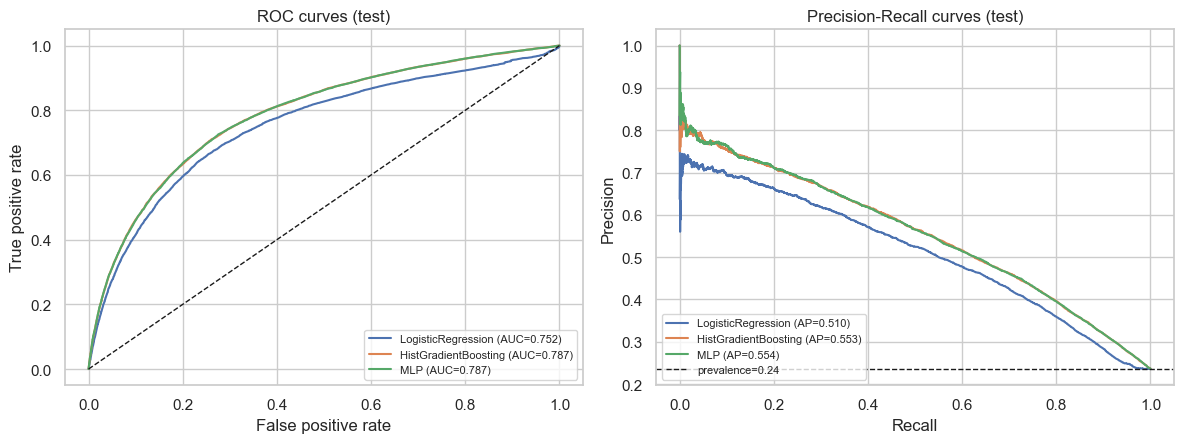

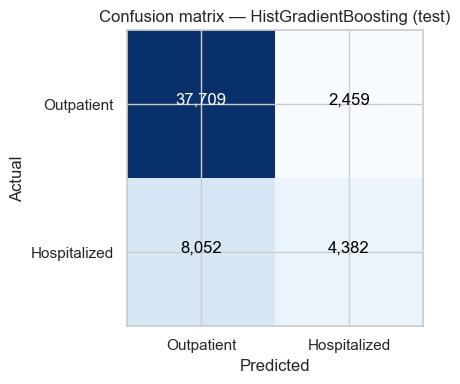

Classification report — HistGradientBoosting (test):

              precision    recall  f1-score   support

  Outpatient       0.82      0.94      0.88     40168
Hospitalized       0.64      0.35      0.45     12434

    accuracy                           0.80     52602
   macro avg       0.73      0.65      0.67     52602
weighted avg       0.78      0.80      0.78     52602



In [11]:
# ---------------------------------------------------------------------------
# 8b. ROC + PR curves (test) and confusion matrix for the winner
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for name, gs in searches.items():
    est = gs.best_estimator_
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (test)"); axes[0].legend(loc="lower right", fontsize=8)
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label=f"prevalence={y_test.mean():.2f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (test)"); axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

# Confusion matrix + report for the winner
best_est = searches[winner].best_estimator_
pred = best_est.predict(X_test)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Outpatient", "Hospitalized"])
ax.set_yticklabels(["Outpatient", "Hospitalized"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {winner} (test)")
thr = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center",
                color="white" if cm[i, j] > thr else "black")
plt.tight_layout(); plt.show()

print(f"Classification report — {winner} (test):\n")
print(classification_report(y_test, pred, target_names=["Outpatient", "Hospitalized"],
                            zero_division=0))

## 9. Summary & next phase

- The data is now **model-ready**: leakage-safe features only, a saved stratified split, and all learned preprocessing wrapped inside pipelines.
- Three families were tuned within a ~200-fit budget on stratified 5-fold CV; the winner was chosen on CV ROC-AUC and evaluated once on the held-out test set, reported across accuracy, precision, recall, F1, ROC-AUC and PR-AUC.
- **Next phase (Section C):** a deeper error analysis on the winner — where it fails by age band, sex, and comorbidity burden; whether failures indicate systematic bias, data-quality issues, or a genuine limit of predictability — plus probability calibration if you intend to use the scores for triage.

**AI-assistance disclosure (adapt for your citation policy):** *An AI assistant (Claude) was used to scaffold this modeling notebook — pipeline structure, the ablation harness, and the experimental design. The target choice, modeling decisions, and interpretation of results are the author's own.*